In [1]:
using Plots, DifferentialEquations, LaTeXStrings
include("imode_sigmoid.jl")
using .ImodeSigmoid

## 4-neuron CPG simulation
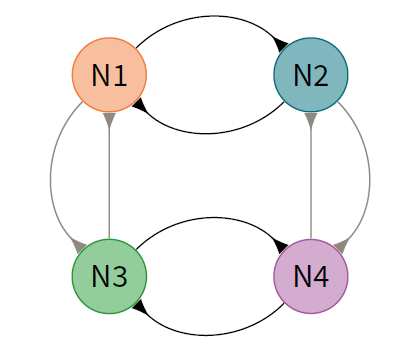

The neurons are the same as before, and the synapse is just a filter summing up whichever inputs each neuron is receiving

In [2]:
function Network!(du,u,p,t)

	neuron_currents = u[1:4:n_neurons*4] .- Idc/2
	neuron_currents[neuron_currents .< 0] .= 0

	for i = 1:n_neurons
		If, Is, Ius, Isyn = u[4*i-3:4*i]

		sigf_pars = (Ithr=Ithr_f, Igain=Igain_f-Is, Ilin=Ilin_f)
		sigs_pars = (Ithr=Ithr_s, Igain=Igain_s-Ius, Ilin=Ilin_s)

		du[4*i-3] = (-If - Is - Ius + Imode_sigmoid_eval(If, sigf_pars, var_gain=true) + Imode_sigmoid_eval(Is, sigs_pars, var_gain=true) + Isyn) / τ_f
		du[4*i-2] = (-Is + If) / τ_s
		du[4*i-1] = (-Ius + If) / τ_us

		# Synapse
		du[4*i] = (-Isyn + sum(SYN[:,i].*neuron_currents) + Idc) / τ_us
	end
end

Network! (generic function with 1 method)

A synaptic connections matrix is defined with the weight of the connections between each neuron

There was a (quickly abandoned) attempt at defining a neuromodulation matrix for neuromodulatory synapses (that would modulate the gains of the sigmoids within a neuron instead of their input)

In [7]:
SYN = [0 -1 -1 0; -1 0 0 -1; -1 0 0 -1; 0 -1 -1 0]
n_neurons = size(SYN)[1]
if length(size(SYN)) != 2 || size(SYN)[2] != n_neurons
	error("SYN must be a square matrix")
end

# NMD = [0 0 0 0 0; 0 0 0 0 0; 0 0 0 0 0; 0 0 0 0 0; 0.2 0 0 0 0]
# if length(size(NMD)) != 2 || size(NMD)[1] != n_neurons || size(NMD)[2] != n_neurons
# 	error("NMD must be a square matrix the same size as SYN")
# end

In [4]:
τ_f = 0.0001
τ_s = 0.02
τ_us = 0.4

Ithr_f = 150e-9
Igain_f = 700e-9
Ilin_f = 250e-9

Ithr_s = 110e-9
Igain_s = 250e-9
Ilin_s = 50e-9

Idc = 400e-9

4.0e-7

In [5]:
Tfinal = 3.
tspan = (0.0, Tfinal)

x0 = zeros(n_neurons*4) .+ 1e-8
x0[4] = 2e-8 # Perturbation to avoid symmetry
x0[12] = 2e-8 # Perturbation to avoid symmetry

pars = (Ithr_f, Igain_f, Ilin_f, Ithr_s, Igain_s, Ilin_s)

prob = ODEProblem(Network!, x0, tspan, pars)
sol = solve(prob, Rodas4P(), abstol=1e-12, reltol=1e-9);

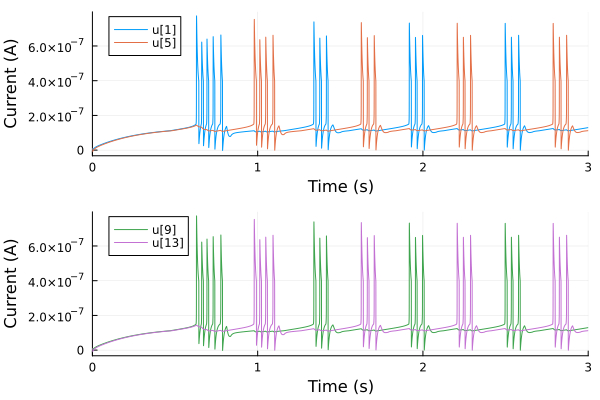

In [ ]:
plot(sol, idxs=[1, 5], layout=(2, 1), subplot=1, xlabel="Time (s)", ylabel="Current (A)")
plot!(sol, idxs=[9, 13], layout=(2, 1), subplot=2, xlabel="Time (s)", ylabel="Current (A)", color=[3 4])
